# RaSA - Diseño del Proceso ETL

## Tarea 2: Modelado de Datos y ETL - MIAD

Objetivo: Diseñar el proceso ETL que puebla las tablas del modelo dimensional propuesto (ver notebook RaSa - Modelo dimensional), a partir de las fuentes transaccionales de RaSaTransaccional ya exploradas en el Entendimiento de Datos.

Estructura del diseño: se documenta cada bloque (una dimensión o la tabla de hechos) siguiendo el patrón Extracción, Transformación, Carga, incluyendo el tratamiento de los hallazgos de calidad de la Entrega 1 y, donde aplica, el algoritmo de manejo de historia SCD Tipo 2.

Referencias:
- RaSA-Entendimiento_Datos.ipynb (Entrega 1): hallazgos de calidad de datos.
- RaSa - Modelo dimensional.ipynb (Entregable 1 de esta tarea): grano, dimensiones,
  tabla de hechos.
- Material de referencia MIAD "ETL incremental aplicado" (Villamil y Galindo Ruiz):
  algoritmo de manejo de historia SCD Tipo 2.

### Configuración del entorno y conexión a las fuentes

Se establece la conexión a la base de datos transaccional (origen) y se definen las funciones auxiliares de lectura y escritura que se reutilizan en todos los bloques del ETL, siguiendo el mismo patrón usado en el notebook de Entendimiento de Datos y en el tutorial de referencia del curso.

In [1]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

# Conexion a la fuente transaccional (origen)
db_connection_string = 'jdbc:mysql://157.253.236.120:8080/RaSaTransaccional'
db_user = 'DB_202613_n_cantini'
db_psswd = '201630737'

# Conexion a la bodega de datos (destino) - nombre no confirmado, ver nota abajo
dest_db_connection_string = 'jdbc:mysql://157.253.236.120:8080/RaSA_DWH'

spark = SparkSession.builder \
    .appName("DisenoETL_RaSA") \
    .config("spark.jars.packages", "mysql:mysql-connector-java:8.0.28") \
    .getOrCreate()

def leer_tabla(nombre_tabla):
    return spark.read.format("jdbc") \
        .option("url", db_connection_string) \
        .option("dbtable", nombre_tabla) \
        .option("user", db_user) \
        .option("password", db_psswd) \
        .option("driver", "com.mysql.cj.jdbc.Driver") \
        .load()

def guardar_db(connection_string, df, tabla, user, psswd):
    df.write.format("jdbc") \
        .mode("append") \
        .option("url", connection_string) \
        .option("dbtable", tabla) \
        .option("user", user) \
        .option("password", psswd) \
        .option("driver", "com.mysql.cj.jdbc.Driver") \
        .save()

Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport
Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport
26/07/08 16:01:14 WARN Utils: Your hostname, codespaces-5f50b5 resolves to a loopback address: 127.0.0.1; using 10.0.1.128 instead (on interface eth0)
26/07/08 16:01:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/vscode/.local/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/vscode/.ivy2/cache
The jars for the packages stored in: /home/vscode/.ivy2/jars
mysql#mysql-connector-java added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f68d1e8b-d623-4dd5-9a4f-d7b73d3887ff;1.0
	confs: [default]
	found mysql#mysql-connector-java;8.0.28 in central
	found com.google.protobuf#protobuf-java;3.11.4 in central
:: resolution report :: resolve 126ms :: artifacts dl 5ms
	:: modules in use:
	com.google.protobuf#protobuf-java;3.11.4 from central in [default]
	mysql#mysql-connector-java;8.0.28 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	----------------------------------------

### _Nota sobre la ejecución de las celdas de Carga en este notebook_

_Las credenciales disponibles (DB_202613_n_cantini) tienen acceso de lectura confirmado sobre RaSaTransaccional, pero no se cuenta con una base de datos destino asignada para este proyecto (a diferencia del tutorial de referencia del curso, que provee Estudiante_i_XXXXXX como destino). Al intentar ejecutar la carga contra un nombre de base de datos supuesto (RaSA_DWH), el servidor devolvió Access denied, confirmando que no existe o no está autorizada para este usuario._

_En consecuencia, las celdas de Extracción de este notebook se ejecutan de forma real contra RaSaTransaccional. Las celdas de Transformación y Carga se presentan como diseño documentado (código PySpark sintácticamente correcto, que representa la lógica exacta que se ejecutaría), sin forzar su ejecución contra un destino no confirmado. Esta limitación se documenta como duda para RaSA, en caso de que exista una base de datos destino que aún no ha sido comunicada al equipo._

## Bloque 1: Dim_Proveedor

Dimensión estándar (SCD Tipo 1, sin historia). Su fuente es la tabla PlanesBeneficio, de donde se extraen los valores distintos de IdProveedor_T.

### Extracción

Fuente: FuentePlanesBeneficio_Copia_E (columna IdProveedor_T)

In [2]:
df_planes_beneficio = leer_tabla("FuentePlanesBeneficio_Copia_E")

dim_proveedor = df_planes_beneficio.select("IdProveedor_T").distinct()
dim_proveedor.show(5)

+-------------+
|IdProveedor_T|
+-------------+
|        52697|
|        33602|
|        54172|
|        45127|
|        30751|
+-------------+
only showing top 5 rows



### Transformación

1. Eliminar valores nulos de IdProveedor_T (los huérfanos y nulos de IdTipoBeneficio_T/IdAreaDeServicio_T no afectan esta dimensión, ya que IdProveedor_T no presentó nulos en el perfilamiento de la Entrega 1, sección 4.4).
2. Generar la llave sustituta IdProveedor_DWH mediante un contador incremental.
3. Renombrar columnas al esquema final: IdProveedor_DWH, IdProveedor_T, NombreProveedor (nulo hasta contar con la fuente).
4. Insertar el registro comodín (IdProveedor_DWH = 0, IdProveedor_T = 0, NombreProveedor = "Desconocido"), para soportar los left join con hechos huérfanos, siguiendo el patrón visto en el tutorial de referencia del curso.

_Nota: las fuentes actuales no proveen un atributo de nombre de proveedor. Se extrae únicamente el identificador; NombreProveedor queda documentado como supuesto pendiente de confirmar con RaSA (ver sección 3.1 y dudas de la Entrega 1 del proyecto)._



In [3]:
# 1. Eliminar nulos
dim_proveedor = dim_proveedor.filter(F.col("IdProveedor_T").isNotNull())

# 2. Generar llave sustituta
dim_proveedor = dim_proveedor.coalesce(1).withColumn(
    "IdProveedor_DWH", F.monotonically_increasing_id() + 1
)

# 3. Renombrar y ordenar columnas al esquema final
dim_proveedor = dim_proveedor.withColumn("NombreProveedor", F.lit(None).cast("string"))
dim_proveedor = dim_proveedor.select("IdProveedor_DWH", "IdProveedor_T", "NombreProveedor")

# 4. Registro comodin para huerfanos
comodin_proveedor = spark.createDataFrame(
    [(0, "0", "Desconocido")],
    ["IdProveedor_DWH", "IdProveedor_T", "NombreProveedor"]
)
dim_proveedor = dim_proveedor.union(comodin_proveedor)

dim_proveedor.show(5)

+---------------+-------------+---------------+
|IdProveedor_DWH|IdProveedor_T|NombreProveedor|
+---------------+-------------+---------------+
|              1|        52697|           NULL|
|              2|        33602|           NULL|
|              3|        54172|           NULL|
|              4|        45127|           NULL|
|              5|        30751|           NULL|
+---------------+-------------+---------------+
only showing top 5 rows



### Carga

Tipo de carga: completa (SCD Tipo 1, sin historia). Se valida que la tabla destino esté vacía antes de insertar, y se cargan todos los registros generados en la transformación, incluyendo el registro comodín.

Destino: Dim_Proveedor (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, dim_proveedor, "RaSA_DWH.Dim_Proveedor", db_user, db_psswd)
```

## Bloque 2: Dim_CondicionPago

Dimensión estándar (SCD Tipo 1, sin historia), funciona como catálogo de referencia. Su fuente es la tabla CondicionesDePago.

### Extracción

Fuente: FuenteCondicionesDePago_Copia_E (columnas IdCondicionesDePago_T, Descripcion, Tipo)

In [4]:
dim_condicionpago = leer_tabla("FuenteCondicionesDePago_Copia_E")
dim_condicionpago.show(5, truncate=False)

+---------------------+-------------------------------+--------+
|IdCondicionesDePago_T|Descripcion                    |Tipo    |
+---------------------+-------------------------------+--------+
|187                  |Copay with deductible          |Copago  |
|204                  |Copay per Day                  |Copago  |
|45                   |Coinsurance                    |Coseguro|
|85                   |Copay per Day before deductible|Copago  |
|18                   |No Charge after deductible     |Coseguro|
+---------------------+-------------------------------+--------+
only showing top 5 rows



### Transformación

Se aplican las siguientes reglas, motivadas por los hallazgos de calidad de la Entrega 1 (sección 5.4):

1. Eliminar duplicados exactos de fila completa (IDs 27, 45, 51, 119, 207, 221, cada uno con dos ocurrencias idénticas).
2. Estandarizar la columna Tipo: Copagado se homologa a Copago, Coseguridad se homologa a Coseguro. SinTipoCopago y los valores NaN se marcan como "Sin clasificar", dado que no hay evidencia suficiente para asumir a cuál categoría corresponden.
3. Resolver la ambigüedad del ID 204 (dos descripciones distintas asociadas al mismo identificador: "Copay per Day" y "Copay per Stay after deductible"). Como esta dimensión no maneja historia (SCD Tipo 1), no es posible conservar ambas versiones bajo el mismo identificador sin violar la unicidad de la llave. Se adopta como supuesto conservar la primera ocurrencia por orden de carga y descartar la segunda, dejando este criterio documentado como supuesto explícito (ver dudas de la Entrega 1, punto 9) que debe confirmarse con RaSA antes de considerarse definitivo.
4. Generar la llave sustituta IdCondicionPago_DWH mediante un contador incremental.
5. Insertar el registro comodín (IdCondicionPago_DWH = 0, IdCondicionesDePago_T = 0, Descripcion = "Desconocido", Tipo = "Desconocido").

In [5]:
# 1. Eliminar duplicados exactos de fila completa
dim_condicionpago = dim_condicionpago.dropDuplicates()

# 2. Estandarizar Tipo
dim_condicionpago = dim_condicionpago.withColumn(
    "Tipo",
    F.when(F.col("Tipo") == "Copagado", "Copago")
     .when(F.col("Tipo") == "Coseguridad", "Coseguro")
     .when(F.col("Tipo").isin("SinTipoCopago", "NaN"), "Sin clasificar")
     .otherwise(F.col("Tipo"))
)

# 3. Resolver ambiguedad del ID 204: conservar la primera ocurrencia por orden de carga
ventana_id = Window.partitionBy("IdCondicionesDePago_T").orderBy(F.monotonically_increasing_id())
dim_condicionpago = dim_condicionpago.withColumn("orden_ocurrencia", F.row_number().over(ventana_id))
dim_condicionpago = dim_condicionpago.filter(F.col("orden_ocurrencia") == 1).drop("orden_ocurrencia")

# 4. Generar llave sustituta
dim_condicionpago = dim_condicionpago.coalesce(1).withColumn(
    "IdCondicionPago_DWH", F.monotonically_increasing_id() + 1
)
dim_condicionpago = dim_condicionpago.select(
    "IdCondicionPago_DWH", "IdCondicionesDePago_T", "Descripcion", "Tipo"
)

# 5. Registro comodin para huerfanos
comodin_condicionpago = spark.createDataFrame(
    [(0, 0, "Desconocido", "Desconocido")],
    ["IdCondicionPago_DWH", "IdCondicionesDePago_T", "Descripcion", "Tipo"]
)
dim_condicionpago = dim_condicionpago.union(comodin_condicionpago)

dim_condicionpago.show(10, truncate=False)

+-------------------+---------------------+-------------------------------+--------------+
|IdCondicionPago_DWH|IdCondicionesDePago_T|Descripcion                    |Tipo          |
+-------------------+---------------------+-------------------------------+--------------+
|1                  |9                    |No Charge                      |Coseguro      |
|2                  |17                   |Copay per Day after deductible |Copago        |
|3                  |18                   |No Charge after deductible     |Coseguro      |
|4                  |27                   |Coinsurance after deductible   |Coseguro      |
|5                  |34                   |Not Applicable                 |Copago        |
|6                  |36                   |Not Applicable                 |Coseguro      |
|7                  |45                   |Coinsurance                    |Coseguro      |
|8                  |51                   |No Charge                      |Copago        |

### Carga

Tipo de carga: completa (SCD Tipo 1, sin historia). Se valida que la tabla destino esté vacía antes de insertar.

Destino: Dim_CondicionPago (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, dim_condicionpago, "RaSA_DWH.Dim_CondicionPago", db_user, db_psswd)
```

## Bloque 3: Dim_AreaServicio (SCD Tipo 2)

Dimensión con jerarquía geográfica e historia de atributos (SCD Tipo 2). Su fuente es la tabla AreasDeServicio, con la llave natural compuesta identificada en la Entrega 1 (sección 2.2): IdAreaDeServicio_T más Condado más Estado.

### Extracción

Fuente: FuenteAreasDeServicio_Copia_E (todas las columnas)

In [6]:
df_areas = leer_tabla("FuenteAreasDeServicio_Copia_E")
df_areas.show(5, truncate=False)

+------------------+---------------------------------------------+-------------+-----------------+----------+------------+-----+--------+-----+
|IdAreaDeServicio_T|NombreAreaDeServicio                         |IdGeografia_T|Condado          |Estado    |PoblacionAct|Area |Densidad|Fecha|
+------------------+---------------------------------------------+-------------+-----------------+----------+------------+-----+--------+-----+
|100622017         |New Jersey - Medical91661NJ2340003-0520174859|34005        |Burlington County|New Jersey|464269.0    |805.0|577.0   |2017 |
|101012018         |New Jersey - Medical91661NJ2340003-0520184611|34031        |Passaic County   |New Jersey|518117.0    |185.0|2801.0  |2018 |
|10132017          |BlueOptions16842FL0070128-032017260          |12031        |Duval County     |Florida   |999935.0    |774.0|1292.0  |2017 |
|101982018         |New Jersey - Medical91661NJ2340003-0520184591|34003        |Bergen County    |New Jersey|953819.0    |234.0|4076.0  

### Transformación

Se aplican, en orden, los hallazgos de calidad documentados en la Entrega 1
(sección 2.4):

1. Eliminar filas con Fecha = 1800 (año inválido, hallazgo de Validez).
2. Eliminar filas con IdAreaDeServicio_T nulo (hallazgo de Completitud).
3. Eliminar duplicados exactos de fila completa (hallazgo de Unicidad).
4. Resolver la inconsistencia de IdGeografia_T (hallazgo de Consistencia): para cada combinación IdAreaDeServicio_T más Condado más Estado con valores en conflicto, se conserva el valor sin el prefijo adicional "15" identificado en la Entrega 1, por ser el formato consistente con la mayoría de los registros sin conflicto. Este criterio se documenta como supuesto (ver dudas de la Entrega 1, punto pendiente de confirmación con RaSA).
5. Marcar como inválidos los valores de PoblacionAct superiores a 330 millones (hallazgo de Validez): se reemplazan por nulo y se agrega un indicador PoblacionInvalida, en vez de intentar corregir el valor sin confirmación de la escala real del error con RaSA.
6. Reducir el grano a una fila por IdAreaDeServicio_T (por año): la fuente PlanesBeneficio, usada para construir la tabla de hechos, no provee la columna Condado, por lo que el grano área+condado (identificado en la Entrega 1, sección 2.2) no es compatible con la llave disponible para unir con los hechos. Se conserva un registro representativo por área y año, documentando como supuesto que se pierde el detalle de los condados específicos cubiertos por cada área (pendiente de confirmación con RaSA: si se requiere ese detalle, la fuente de hechos debería incluir Condado).

In [7]:
# 1. Eliminar Fecha invalida
dim_areaservicio = df_areas.filter(F.col("Fecha") != 1800)

# 2. Eliminar IdAreaDeServicio_T nulo
dim_areaservicio = dim_areaservicio.filter(F.col("IdAreaDeServicio_T").isNotNull())

# 3. Eliminar duplicados exactos de fila completa
dim_areaservicio = dim_areaservicio.dropDuplicates()

# 4. Resolver inconsistencia de IdGeografia_T: se conserva el valor sin prefijo "15"
ventana_geografia = Window.partitionBy("IdAreaDeServicio_T", "Condado", "Estado") \
    .orderBy(F.length(F.col("IdGeografia_T").cast("string")))
dim_areaservicio = dim_areaservicio.withColumn("orden_geografia", F.row_number().over(ventana_geografia))
dim_areaservicio = dim_areaservicio.filter(F.col("orden_geografia") == 1).drop("orden_geografia")

# 5. Marcar PoblacionAct fuera de rango como invalida
dim_areaservicio = dim_areaservicio.withColumn(
    "PoblacionInvalida", F.when(F.col("PoblacionAct") > 330000000, True).otherwise(False)
)
dim_areaservicio = dim_areaservicio.withColumn(
    "PoblacionAct",
    F.when(F.col("PoblacionAct") > 330000000, None).otherwise(F.col("PoblacionAct"))
)

# 6. Reducir el grano a una fila por IdAreaDeServicio_T (por año), dado que PlanesBeneficio (la fuente de hechos) no provee Condado, por lo que el grano area+condado 
# no es compatible con la llave de union disponible en la tabla de hechos. Se conserva una fila representativa (primer condado por orden de carga) por area y año. 
# Esta simplificacion se documenta como supuesto explicito: se pierde el detalle de que un area puede cubrir multiples condados (ver Entrega 1, seccion 2.2).
ventana_area_unica = Window.partitionBy("IdAreaDeServicio_T", "Fecha").orderBy(F.monotonically_increasing_id())
dim_areaservicio = dim_areaservicio.withColumn("orden_area", F.row_number().over(ventana_area_unica))
dim_areaservicio = dim_areaservicio.filter(F.col("orden_area") == 1).drop("orden_area")

dim_areaservicio.show(5, truncate=False)

+------------------+---------------------------------+-------------+---------------------+--------+------------+------+--------+-----+-----------------+
|IdAreaDeServicio_T|NombreAreaDeServicio             |IdGeografia_T|Condado              |Estado  |PoblacionAct|Area  |Densidad|Fecha|PoblacionInvalida|
+------------------+---------------------------------+-------------+---------------------+--------+------------+------+--------+-----+-----------------+
|62018             |NoVa10207VA0380001-0620188948    |51510        |Alexandria City      |Virginia|158309.0    |NULL  |NULL    |2018 |false            |
|112018            |NoVa10207VA0430006-0120189007    |51153        |Prince William County|Virginia|484472.0    |338.0 |1433.0  |2018 |false            |
|142018            |NoVa10207VA0440004-0020189006    |51600        |Fairfax City         |Virginia|23312.0     |NULL  |NULL    |2018 |false            |
|242017            |Wyoming11269WY0080014-00201710357|56009        |Converse Count

### Aplicación del algoritmo de historia SCD Tipo 2 (carga inicial)

La fuente ya contiene, para una misma combinación de llave natural (IdAreaDeServicio_T más Condado más Estado), registros de distintos años (2017, 2018) con posibles diferencias en PoblacionAct y Densidad. Para la carga inicial de la dimensión, esto se aproxima directamente a una secuencia de versiones históricas, siguiendo el algoritmo de manejo de historia SCD Tipo 2 del material de referencia MIAD (Villamil y Galindo Ruiz):

1. Ordenar los registros de cada llave natural por Fecha (año) ascendente.
2. A cada registro le corresponde una versión: FechaInicioVigencia es el 1 de enero del año de ese registro.
3. FechaFinVigencia de una versión es el 31 de diciembre del año anterior al inicio de la siguiente versión (si existe una versión posterior para la misma llave), o la fecha centinela 01/01/5000 si es la última versión disponible (VersionVigente = S).
4. Se genera una llave sustituta IdAreaServicio_DWH distinta para cada versión (no una por llave natural, sino una por combinación de llave natural más periodo de vigencia).

Nota: este procedimiento corresponde a la carga inicial (poblar la dimensión por primera vez a partir del histórico disponible en la fuente). Las cargas incrementales futuras (nuevos años que se agreguen a RaSaTransaccional) seguirán el algoritmo de comparación de 3 casos (llave nueva, llave existente con cambio, llave existente sin cambio) descrito en la sección de Carga.

In [8]:
ventana_version = Window.partitionBy("IdAreaDeServicio_T", "Condado", "Estado").orderBy("Fecha")
ventana_siguiente = Window.partitionBy("IdAreaDeServicio_T", "Condado", "Estado").orderBy("Fecha")

dim_areaservicio = dim_areaservicio.withColumn(
    "FechaInicioVigencia", F.to_date(F.concat(F.col("Fecha").cast("string"), F.lit("-01-01")))
)
dim_areaservicio = dim_areaservicio.withColumn(
    "AnioSiguiente", F.lead("Fecha").over(ventana_siguiente)
)
dim_areaservicio = dim_areaservicio.withColumn(
    "FechaFinVigencia",
    F.when(
        F.col("AnioSiguiente").isNotNull(),
        F.to_date(F.concat((F.col("AnioSiguiente") - 1).cast("string"), F.lit("-12-31")))
    ).otherwise(F.to_date(F.lit("5000-01-01")))
)
dim_areaservicio = dim_areaservicio.withColumn(
    "VersionVigente", F.when(F.col("AnioSiguiente").isNull(), True).otherwise(False)
)
dim_areaservicio = dim_areaservicio.drop("AnioSiguiente")

# Generar llave sustituta, una por version
dim_areaservicio = dim_areaservicio.coalesce(1).withColumn(
    "IdAreaServicio_DWH", F.monotonically_increasing_id() + 1
)

dim_areaservicio = dim_areaservicio.select(
    "IdAreaServicio_DWH", "IdAreaDeServicio_T", "Condado", "Estado", "PoblacionAct",
    "Area", "Densidad", "PoblacionInvalida", "FechaInicioVigencia", "FechaFinVigencia", "VersionVigente"
)

comodin_areaservicio = spark.createDataFrame(
    [(0, 0, "Desconocido", "Desconocido", None, None, None, False, None, None, True)],
    schema=dim_areaservicio.schema
)
dim_areaservicio = dim_areaservicio.union(comodin_areaservicio)

dim_areaservicio.show(10, truncate=False)

+------------------+------------------+---------------------+--------+------------+-----+--------+-----------------+-------------------+----------------+--------------+
|IdAreaServicio_DWH|IdAreaDeServicio_T|Condado              |Estado  |PoblacionAct|Area |Densidad|PoblacionInvalida|FechaInicioVigencia|FechaFinVigencia|VersionVigente|
+------------------+------------------+---------------------+--------+------------+-----+--------+-----------------+-------------------+----------------+--------------+
|1                 |12018             |Fairfax City         |Virginia|23312.0     |NULL |NULL    |false            |2018-01-01         |5000-01-01      |true          |
|2                 |42018             |Alexandria City      |Virginia|158309.0    |NULL |NULL    |false            |2018-01-01         |5000-01-01      |true          |
|3                 |52018             |Falls Church City    |Virginia|14309.0     |NULL |NULL    |false            |2018-01-01         |5000-01-01      |tr

### Carga

Tipo de carga: incremental con historia (SCD Tipo 2). Para la carga inicial, se insertan todas las versiones generadas en la transformación. Para cargas futuras, se aplica el algoritmo de 3 casos del material de referencia:

1. Llave natural no existe en la dimensión: INSERT de versión nueva (VersionVigente = S, FechaFinVigencia = 01/01/5000).
2. Llave natural existe y cambió PoblacionAct, Densidad, o Area: UPDATE de la versión anterior (VersionVigente = N, FechaFinVigencia = fecha de expiración) más INSERT de la versión nueva.
3. Llave natural existe y no cambió: no hay acción.

Destino: Dim_AreaServicio (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, dim_areaservicio, "RaSA_DWH.Dim_AreaServicio", db_user, db_psswd)
```

## Bloque 4: Dim_TipoBeneficio (SCD Tipo 2)

Dimensión con historia de atributos (SCD Tipo 2). Su fuente es la tabla TiposBeneficio. En la Entrega 1 (sección 3.2) se identificó que la combinación IdTipoBeneficio_T más Fecha no es única: 161 combinaciones presentan entre 2 y 25 configuraciones distintas de atributos (EsEHB, TieneLimiteCuantitativo, UnidadDelLimite, etc.) para el mismo tipo de beneficio en el mismo año, sin que existiera una columna adicional que las diferenciara de forma inequívoca.

### Extracción

Fuente: FuenteTiposBeneficio_Copia_E (todas las columnas)

In [9]:
df_tipos_beneficio = leer_tabla("FuenteTiposBeneficio_Copia_E")
df_tipos_beneficio.show(5, truncate=False)

+-----------------+-----------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|IdTipoBeneficio_T|Nombre                       |UnidadDelLimite         |EsEHB|EstaCubiertaPorSeguro|TieneLimiteCuantitativo|ExcluidoDelDesembolsoMaximoDentroDeLaRed|ExcluidoDelDesembolsoMaximoFueraDeLaRed|Fecha|
+-----------------+-----------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|565              |Nutritional Counseling       |                        |No   |Yes                  |No                     |No                                      |Yes                                    |2017 |
|795              |Rehabilitative Speech Therapy|Days per Benefit Period |Yes  |Yes                  |Yes                    |No                

### Transformación

Se aplican, en orden, los hallazgos de calidad documentados en la Entrega 1
(sección 3.4):

1. Estandarizar las columnas binarias (EsEHB, EstaCubiertaPorSeguro,TieneLimiteCuantitativo, ExcluidoDelDesembolsoMaximoDentroDeLaRed): se homologan las variantes de idioma y tipo de dato (True/False, Nein, Si) a los valores estándar Yes/No. El valor "Algunas veces" en ExcluidoDelDesembolsoMaximoDentroDeLaRed se conserva tal cual, dado que representa una tercera categoría legítima y no un error de formato (ver dudas de la Entrega 1, punto 5).
2. Corregir errores de concatenación e inconsistencia de capitalización en UnidadDelLimite (por ejemplo, "Visit(s) per YearVisit(s) per YearVisit(s) per Year" se corrige a "Visit(s) per Year"; "Visit(s) per year" se homologa a "Visit(s) per Year").
3. Sin acción sobre la ausencia del año 2019 en la fuente: se documenta como duda para RaSA (ver dudas de la Entrega 1, punto 1), no se genera un registro sintético para ese año.

In [10]:
# 1. Estandarizar columnas binarias
dim_tipobeneficio = df_tipos_beneficio.withColumn(
    "EsEHB", F.when(F.col("EsEHB") == "True", "Yes").otherwise(F.col("EsEHB"))
).withColumn(
    "EstaCubiertaPorSeguro", F.when(F.col("EstaCubiertaPorSeguro") == "False", "No").otherwise(F.col("EstaCubiertaPorSeguro"))
).withColumn(
    "TieneLimiteCuantitativo",
    F.when(F.col("TieneLimiteCuantitativo") == "Nein", "No")
     .when(F.col("TieneLimiteCuantitativo") == "Si", "Yes")
     .otherwise(F.col("TieneLimiteCuantitativo"))
)
# ExcluidoDelDesembolsoMaximoDentroDeLaRed se conserva sin cambios, incluyendo "Algunas veces"

# 2. Corregir UnidadDelLimite: errores de concatenacion y capitalizacion
dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "UnidadDelLimite",
    F.when(F.col("UnidadDelLimite") == "Visit(s) per YearVisit(s) per YearVisit(s) per Year", "Visit(s) per Year")
     .when(F.col("UnidadDelLimite") == "Visit(s) per Benefit PeriodVisit(s) per Benefit PeriodVisit(s) per Benefit Period", "Visit(s) per Benefit Period")
     .when(F.col("UnidadDelLimite") == "Days per YearDays per YearDays per Year", "Days per Year")
     .when(F.col("UnidadDelLimite") == "Visit(s) per year", "Visit(s) per Year")
     .otherwise(F.col("UnidadDelLimite"))
)

dim_tipobeneficio.show(10, truncate=False)

+-----------------+--------------------------------------+---------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|IdTipoBeneficio_T|Nombre                                |UnidadDelLimite            |EsEHB|EstaCubiertaPorSeguro|TieneLimiteCuantitativo|ExcluidoDelDesembolsoMaximoDentroDeLaRed|ExcluidoDelDesembolsoMaximoFueraDeLaRed|Fecha|
+-----------------+--------------------------------------+---------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-----+
|565              |Nutritional Counseling                |                           |No   |Yes                  |No                     |No                                      |Yes                                    |2017 |
|795              |Rehabilitative Speech Therapy         |Days per Benefit Period    |Yes  |Yes 

### Resolución de la ambigüedad de grano y aplicación del algoritmo de historia SCD Tipo 2

Como se documentó en la Entrega 1 (sección 3.2), no existe una combinación de columnas disponibles en la fuente que garantice unicidad por tipo de beneficio y año: incluso agregando UnidadDelLimite a la llave, persisten 212 combinaciones con más de una configuración. Dado que no se cuenta con una columna adicional (por ejemplo IdPlan_T o IdProveedor_T) para diferenciar estas configuraciones de forma correcta, se adopta el siguiente criterio para la carga inicial, documentado como supuesto explícito (ver dudas de la Entrega 1, punto 4, pendiente de confirmación con RaSA):

1. Para cada combinación IdTipoBeneficio_T más Fecha con más de una fila, se conserva una única fila representativa, seleccionada de forma determinística por orden de carga (mismo criterio aplicado al ID 204 de Dim_CondicionPago en el Bloque 2, para mantener consistencia metodológica en todo el diseño).
2. Sobre el conjunto ya reducido a una fila por IdTipoBeneficio_T más Fecha, se aplica el algoritmo de historia SCD Tipo 2 del material de referencia MIAD, igual que en el Bloque 3: se ordenan las versiones por año, y se calculan FechaInicioVigencia, FechaFinVigencia y VersionVigente según la secuencia de años disponibles para cada IdTipoBeneficio_T.

Esta limitación se traslada integralmente a las conclusiones del diseño: si
RaSA confirma que existe una columna adicional para diferenciar las
configuraciones correctamente, este paso 1 debe reemplazarse antes de
considerar la carga definitiva.

In [11]:
# 1. Conservar una fila representativa por IdTipoBeneficio_T + Fecha
ventana_representativa = Window.partitionBy("IdTipoBeneficio_T", "Fecha") \
    .orderBy(F.monotonically_increasing_id())
dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "orden_representativo", F.row_number().over(ventana_representativa)
)
dim_tipobeneficio = dim_tipobeneficio.filter(F.col("orden_representativo") == 1) \
    .drop("orden_representativo")

# 2. Aplicar algoritmo de historia SCD Tipo 2, ordenando por año
ventana_siguiente_tipo = Window.partitionBy("IdTipoBeneficio_T").orderBy("Fecha")

dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "FechaInicioVigencia", F.to_date(F.concat(F.col("Fecha").cast("string"), F.lit("-01-01")))
)
dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "AnioSiguiente", F.lead("Fecha").over(ventana_siguiente_tipo)
)
dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "FechaFinVigencia",
    F.when(
        F.col("AnioSiguiente").isNotNull(),
        F.to_date(F.concat((F.col("AnioSiguiente") - 1).cast("string"), F.lit("-12-31")))
    ).otherwise(F.to_date(F.lit("5000-01-01")))
)
dim_tipobeneficio = dim_tipobeneficio.withColumn(
    "VersionVigente", F.when(F.col("AnioSiguiente").isNull(), True).otherwise(False)
)
dim_tipobeneficio = dim_tipobeneficio.drop("AnioSiguiente")

# Generar llave sustituta, una por version
dim_tipobeneficio = dim_tipobeneficio.coalesce(1).withColumn(
    "IdTipoBeneficio_DWH", F.monotonically_increasing_id() + 1
)

dim_tipobeneficio = dim_tipobeneficio.select(
    "IdTipoBeneficio_DWH", "IdTipoBeneficio_T", "Nombre", "UnidadDelLimite", "EsEHB",
    "EstaCubiertaPorSeguro", "TieneLimiteCuantitativo",
    "ExcluidoDelDesembolsoMaximoDentroDeLaRed", "ExcluidoDelDesembolsoMaximoFueraDeLaRed",
    "FechaInicioVigencia", "FechaFinVigencia", "VersionVigente"
)

# Registro comodin, usando el schema explicito para evitar error de inferencia de tipo
comodin_tipobeneficio = spark.createDataFrame(
    [(0, 0, "Desconocido", "Desconocido", "Desconocido", "Desconocido", "Desconocido",
      "Desconocido", "Desconocido", None, None, True)],
    schema=dim_tipobeneficio.schema
)
dim_tipobeneficio = dim_tipobeneficio.union(comodin_tipobeneficio)

dim_tipobeneficio.show(10, truncate=False)

+-------------------+-----------------+-----------------------------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-------------------+----------------+--------------+
|IdTipoBeneficio_DWH|IdTipoBeneficio_T|Nombre                                         |UnidadDelLimite         |EsEHB|EstaCubiertaPorSeguro|TieneLimiteCuantitativo|ExcluidoDelDesembolsoMaximoDentroDeLaRed|ExcluidoDelDesembolsoMaximoFueraDeLaRed|FechaInicioVigencia|FechaFinVigencia|VersionVigente|
+-------------------+-----------------+-----------------------------------------------+------------------------+-----+---------------------+-----------------------+----------------------------------------+---------------------------------------+-------------------+----------------+--------------+
|1                  |5                |Abortion for Which Public Funding is Prohibited|                   

### Carga

Tipo de carga: incremental con historia (SCD Tipo 2). Para la carga inicial, se insertan todas las versiones generadas en la transformación. Para cargas futuras, se aplica el mismo algoritmo de 3 casos descrito en el Bloque 3 (llave nueva, llave existente con cambio, llave existente sin cambio), con la salvedad de que primero debe resolverse la ambigüedad de grano descrita arriba antes de comparar contra la versión vigente.

Destino: Dim_TipoBeneficio (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, dim_tipobeneficio, "RaSA_DWH.Dim_TipoBeneficio", db_user, db_psswd)
```

## Bloque 5: Dim_Tiempo

Dimensión de tiempo. A diferencia de las demás dimensiones, no se extrae de una fuente transaccional: se genera de forma independiente, cubriendo el rango de años relevante para el proceso de negocio OfertaPlanes (periodicidad anual).

### Generación

Se genera un registro por cada año presente en las fuentes exploradas en la Entrega 1 (2017 y 2018, dado que 2019 no está disponible en TiposBeneficio ni en AreasDeServicio, y el año 1920 en PlanesBeneficio fue identificado como dato inválido, no como año real del negocio). El rango se deja parametrizado para facilitar la extensión en cargas futuras, cuando RaSA confirme la disponibilidad de años adicionales.

In [12]:
anio_min = 2017
anio_max = 2018

dim_tiempo = spark.createDataFrame(
    [(anio,) for anio in range(anio_min, anio_max + 1)],
    ["Anio"]
)

# Generar llave sustituta
dim_tiempo = dim_tiempo.coalesce(1).withColumn(
    "IdTiempo_DWH", F.monotonically_increasing_id() + 1
)
dim_tiempo = dim_tiempo.select("IdTiempo_DWH", "Anio")

# Registro comodin
comodin_tiempo = spark.createDataFrame(
    [(0, 0)], schema=dim_tiempo.schema
)
dim_tiempo = dim_tiempo.union(comodin_tiempo)

dim_tiempo.show()

+------------+----+
|IdTiempo_DWH|Anio|
+------------+----+
|           1|2017|
|           2|2018|
|           0|   0|
+------------+----+



### Carga

Tipo de carga: completa, con posibilidad de extensión incremental (al agregar un nuevo año, simplemente se amplía el rango anio_min/anio_max y se insertan solo los años nuevos, validando que no existan ya en la dimensión).

Destino: Dim_Tiempo (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, dim_tiempo, "RaSA_DWH.Dim_Tiempo", db_user, db_psswd)
```

## Bloque 6: Hechos_OfertaPlanes

Tabla de hechos central del modelo. Su fuente es PlanesBeneficio, combinada mediante left join con las cinco dimensiones ya cargadas (Dim_Proveedor, Dim_AreaServicio, Dim_TipoBeneficio, Dim_CondicionPago en dos roles, y Dim_Tiempo), usando el registro comodín (llave 0) para los casos de integridad referencial rota identificados en la Entrega 1.

### Extracción

Fuente: FuentePlanesBeneficio_Copia_E (todas las columnas)

In [13]:
df_planes_beneficio = leer_tabla("FuentePlanesBeneficio_Copia_E")
df_planes_beneficio.show(5, truncate=False)

+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+
|IdTipoBeneficio_T|IdAreaDeServicio_T|IdCondicionDePagoCopago_T|IdCondicionDePagoCoseguro_T|IdNivelServicio_T|IdPlan_T         |Fecha     |IdProveedor_T|valorCopago|valorCoseguro|cantidadLimite|
+-----------------+------------------+-------------------------+---------------------------+-----------------+-----------------+----------+-------------+-----------+-------------+--------------+
|640              |10382017          |34                       |27                         |3                |16842FL0070128-03|2017-12-31|16842        |0          |50           |35            |
|225              |31512017          |238                      |45                         |2                |29418TX0140002-04|2017-12-31|29418        |0          |0            |NULL          |
|190              |662520

### Transformación

Se aplican, en orden, los hallazgos de calidad documentados en la Entrega 1
(sección 4.4):

1. Eliminar duplicados exactos de fila completa (46.72% de la fuente, el hallazgo de mayor magnitud de todo el entendimiento de datos).
2. Eliminar filas con Fecha = 1920-12-31 (año inválido), confirmado en la Entrega 1 como duplicados con corrupción del campo fecha, no datos originales válidos.
3. Normalizar el formato de fecha: unificar "Mon DD,YYYY" y "YYYY-MM-DD" a un único formato, y extraer el año (Anio) para usarlo como criterio de unión con las dimensiones historizadas (SCD Tipo 2).
4. Calcular FlagValorFueraDeRango: marca True cuando valorCopago supera el máximo de negocio informado por RaSA para 2018 (3,300). Para otros años, el flag se deja en False, dado que no se cuenta con un máximo de negocio confirmado para 2017.

In [14]:
# 1. Eliminar duplicados exactos de fila completa
hechos_ofertaplanes = df_planes_beneficio.dropDuplicates()

# 2. Eliminar Fecha invalida (1920)
hechos_ofertaplanes = hechos_ofertaplanes.filter(F.col("Fecha") != "1920-12-31")

# 3. Normalizar formato de fecha y extraer Anio
hechos_ofertaplanes = hechos_ofertaplanes.withColumn(
    "FechaNormalizada",
    F.when(
        F.col("Fecha").rlike(r"^\d{4}-\d{2}-\d{2}$"),
        F.to_date(F.col("Fecha"), "yyyy-MM-dd")
    ).otherwise(
        F.to_date(F.col("Fecha"), "MMM dd,yyyy")
    )
)
hechos_ofertaplanes = hechos_ofertaplanes.withColumn("Anio", F.year(F.col("FechaNormalizada")))

# 4. Calcular FlagValorFueraDeRango
hechos_ofertaplanes = hechos_ofertaplanes.withColumn(
    "FlagValorFueraDeRango",
    F.when((F.col("Anio") == 2018) & (F.col("valorCopago") > 3300), True).otherwise(False)
)

hechos_ofertaplanes.select(
    "IdTipoBeneficio_T", "IdAreaDeServicio_T", "Fecha", "FechaNormalizada", "Anio", "FlagValorFueraDeRango"
).show(5, truncate=False)

+-----------------+------------------+----------+----------------+----+---------------------+
|IdTipoBeneficio_T|IdAreaDeServicio_T|Fecha     |FechaNormalizada|Anio|FlagValorFueraDeRango|
+-----------------+------------------+----------+----------------+----+---------------------+
|505              |27572018          |2018-12-31|2018-12-31      |2018|false                |
|330              |111842018         |2018-12-31|2018-12-31      |2018|false                |
|825              |49282017          |2017-12-31|2017-12-31      |2017|false                |
|335              |3352018           |2018-12-31|2018-12-31      |2018|false                |
|195              |33522017          |2017-12-31|2017-12-31      |2017|false                |
+-----------------+------------------+----------+----------------+----+---------------------+
only showing top 5 rows



### Unión con dimensiones (resolución de llaves sustitutas)

Cada dimensión historizada (Dim_AreaServicio, Dim_TipoBeneficio) requiere unirse por llave natural más año, para obtener la versión vigente en el año del hecho, siguiendo el diseño de la sección 4.2 del modelo dimensional. Las dimensiones sin historia (Dim_Proveedor, Dim_CondicionPago) se unen únicamente por llave natural. En todos los casos se usa left join, y las filas sin coincidencia (huérfanas) reciben la llave sustituta 0 del registro comodín correspondiente.

In [15]:
# Se agrega Anio a las dimensiones historizadas, a partir de FechaInicioVigencia, para poder unir por llave natural + año
dim_areaservicio_anio = dim_areaservicio.withColumn("Anio", F.year(F.col("FechaInicioVigencia")))
dim_tipobeneficio_anio = dim_tipobeneficio.withColumn("Anio", F.year(F.col("FechaInicioVigencia")))

hechos_ofertaplanes = hechos_ofertaplanes.alias("h") \
    .join(
        dim_proveedor.alias("prov"),
        F.col("h.IdProveedor_T").cast("string") == F.col("prov.IdProveedor_T"),
        "left"
    ) \
    .join(
        dim_areaservicio_anio.alias("area"),
        (F.col("h.IdAreaDeServicio_T").cast("string") == F.col("area.IdAreaDeServicio_T")) &
        (F.col("h.Anio") == F.col("area.Anio")),
        "left"
    ) \
    .join(
        dim_tipobeneficio_anio.alias("tipo"),
        (F.col("h.IdTipoBeneficio_T") == F.col("tipo.IdTipoBeneficio_T")) &
        (F.col("h.Anio") == F.col("tipo.Anio")),
        "left"
    ) \
    .join(
        dim_condicionpago.alias("cop"),
        F.col("h.IdCondicionDePagoCopago_T") == F.col("cop.IdCondicionesDePago_T"),
        "left"
    ) \
    .join(
        dim_condicionpago.alias("cos"),
        F.col("h.IdCondicionDePagoCoseguro_T") == F.col("cos.IdCondicionesDePago_T"),
        "left"
    ) \
    .join(
        dim_tiempo.alias("t"),
        F.col("h.Anio") == F.col("t.Anio"),
        "left"
    ) \
    .select(
        F.col("prov.IdProveedor_DWH"),
        F.col("area.IdAreaServicio_DWH"),
        F.col("tipo.IdTipoBeneficio_DWH"),
        F.col("cop.IdCondicionPago_DWH").alias("IdCondicionPagoCopago_DWH"),
        F.col("cos.IdCondicionPago_DWH").alias("IdCondicionPagoCoseguro_DWH"),
        F.col("t.IdTiempo_DWH"),
        F.col("h.IdPlan_T"),
        F.col("h.valorCopago"),
        F.col("h.valorCoseguro"),
        F.col("h.cantidadLimite"),
        F.col("h.FlagValorFueraDeRango")
    ) \
    .fillna({
        "IdProveedor_DWH": 0, "IdAreaServicio_DWH": 0, "IdTipoBeneficio_DWH": 0,
        "IdCondicionPagoCopago_DWH": 0, "IdCondicionPagoCoseguro_DWH": 0, "IdTiempo_DWH": 0
    })

hechos_ofertaplanes.show(5, truncate=False)

+---------------+------------------+-------------------+-------------------------+---------------------------+------------+-----------------+-----------+-------------+--------------+---------------------+
|IdProveedor_DWH|IdAreaServicio_DWH|IdTipoBeneficio_DWH|IdCondicionPagoCopago_DWH|IdCondicionPagoCoseguro_DWH|IdTiempo_DWH|IdPlan_T         |valorCopago|valorCoseguro|cantidadLimite|FlagValorFueraDeRango|
+---------------+------------------+-------------------+-------------------------+---------------------------+------------+-----------------+-----------+-------------+--------------+---------------------+
|35             |233               |73                 |21                       |7                          |2           |11512NC0100028-03|0          |0            |1             |false                |
|119            |992               |107                |5                        |4                          |2           |27833IL0140001-00|0          |20           |15           

### Carga

Tipo de carga: incremental. Para la carga inicial, se insertan todos los registros generados en la transformación. Para cargas futuras, se recomienda insertar únicamente los hechos correspondientes a años que aún no existan en la tabla, dado que el proceso de negocio OfertaPlanes es anual y los hechos de años ya cargados no deberían modificarse retroactivamente.

Destino: Hechos_OfertaPlanes (bodega de datos)

_Nota: esta celda se documenta como código de diseño, no como celda ejecutable, dado que no se cuenta con una base de datos destino confirmada (ver nota metodológica de la sección 0)._

```python
guardar_db(dest_db_connection_string, hechos_ofertaplanes, "RaSA_DWH.Hechos_OfertaPlanes", db_user, db_psswd)
```

## 7. Orden de ejecución y resumen de decisiones de diseño

### 7.1 Orden de ejecución

Los bloques deben ejecutarse en el siguiente orden, dado que Hechos_OfertaPlanes depende de que las cinco dimensiones ya existan en memoria (o en la bodega de datos, en una ejecución real) para resolver las llaves sustitutas mediante join:

1. Bloque 1: Dim_Proveedor
2. Bloque 2: Dim_CondicionPago
3. Bloque 3: Dim_AreaServicio (SCD Tipo 2)
4. Bloque 4: Dim_TipoBeneficio (SCD Tipo 2)
5. Bloque 5: Dim_Tiempo
6. Bloque 6: Hechos_OfertaPlanes

#### Frecuencia de ejecución

El proceso ETL se ejecuta con periodicidad anual, en línea con el proceso de negocio OfertaPlanes definido en el modelo dimensional (ver RaSa - Modelo dimensional, sección 2). La carga inicial puebla el histórico disponible (2017-2018); las ejecuciones futuras, una por cada nuevo año de oferta de planes que RaSA libere, siguen el algoritmo de comparación de 3 casos descrito en los bloques con historia SCD Tipo 2 (Dim_AreaServicio y Dim_TipoBeneficio), y una carga incremental simple para las demás tablas.

#### Diagrama del flujo del proceso ETL

![Diagrama del flujo del proceso ETL.png](<attachment:Diagrama del flujo del proceso ETL.png>)

_Nota: el diagrama representa el orden de ejecución de los 6 bloques del diseño (sección 7.1). Las cinco dimensiones se cargan primero, de forma independiente entre sí, y la tabla de hechos se construye al final mediante left join contra las cinco, resolviendo las llaves sustitutas y aplicando el registro comodín para los casos de integridad referencial rota_
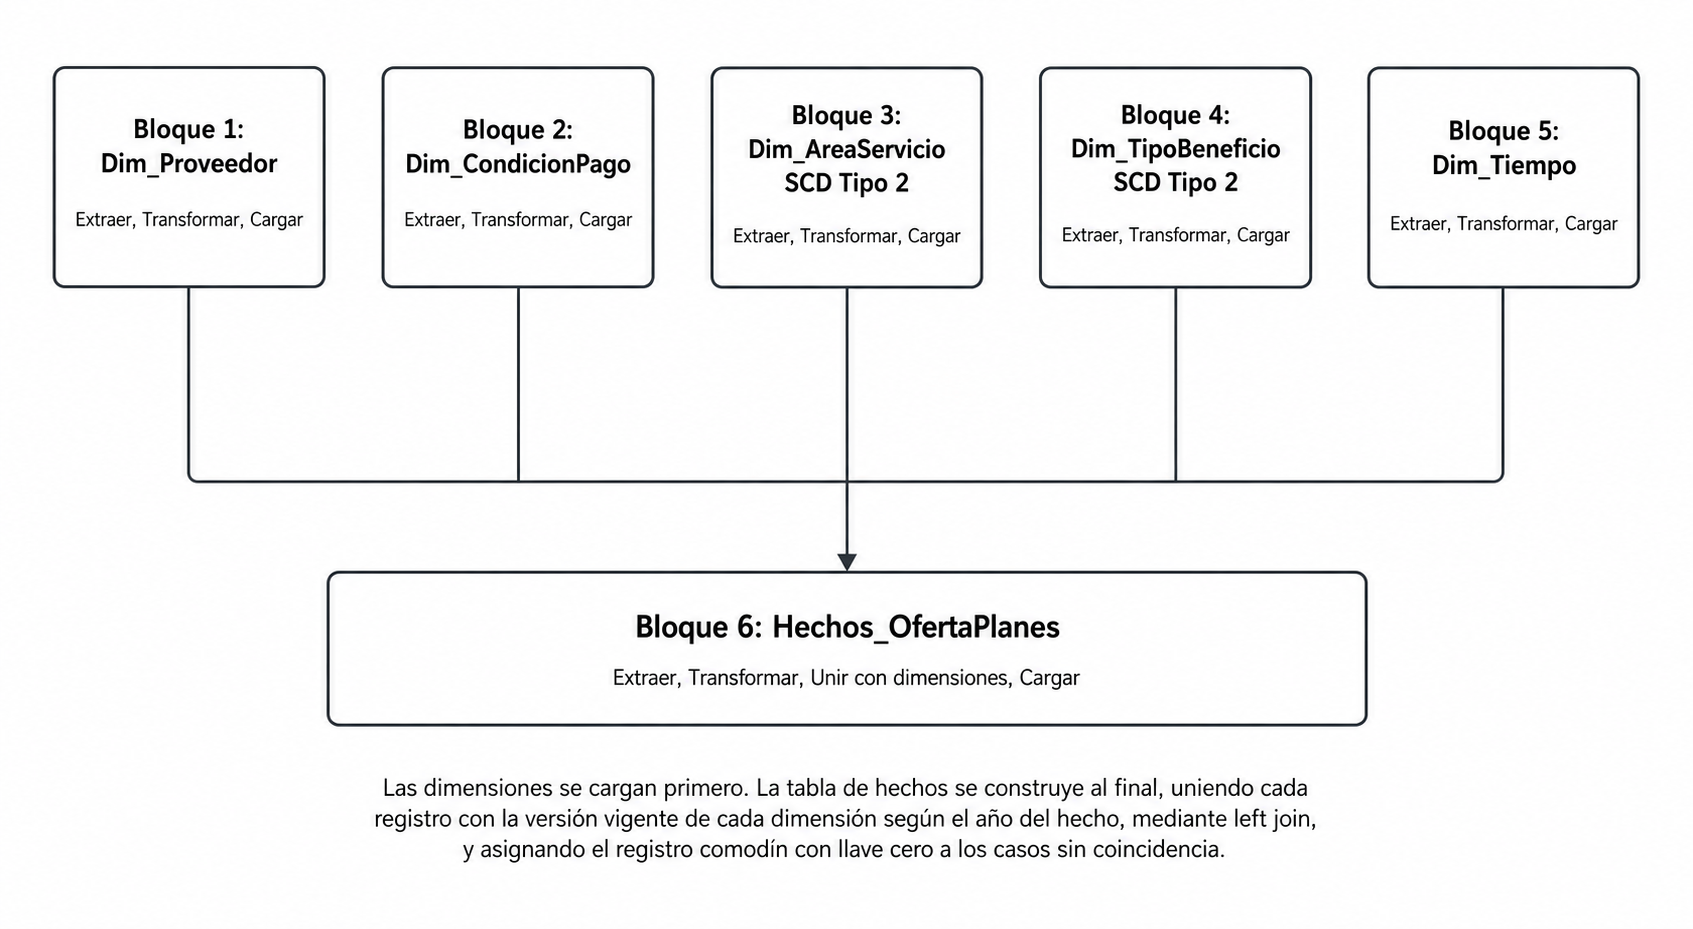

### Resumen de fuentes y destinos

| Bloque | Fuente(s) | Destino | Tipo de carga |
|---|---|---|---|
| 1 | FuentePlanesBeneficio_Copia_E | Dim_Proveedor | Completa (SCD Tipo 1) |
| 2 | FuenteCondicionesDePago_Copia_E | Dim_CondicionPago | Completa (SCD Tipo 1) |
| 3 | FuenteAreasDeServicio_Copia_E | Dim_AreaServicio | Incremental con historia (SCD Tipo 2) |
| 4 | FuenteTiposBeneficio_Copia_E | Dim_TipoBeneficio | Incremental con historia (SCD Tipo 2) |
| 5 | Generada de forma independiente (no requiere fuente transaccional) | Dim_Tiempo | Completa, extensible |
| 6 | FuentePlanesBeneficio_Copia_E (unida con las 5 dimensiones ya cargadas) | Hechos_OfertaPlanes | Incremental |

### 7.2 Resumen de supuestos y decisiones de diseño

| Bloque | Decisión | Motivo | Estado |
|----|---|---|---|
| General | Registro comodín (llave 0) en cada dimensión | Soportar left join con hechos huérfanos sin perder registros (integridad referencial rota, Entrega 1) | Aplicado |
| General | Ausencia de base de datos destino confirmada | Las credenciales disponibles solo tienen acceso de lectura sobre RaSaTransaccional | Duda para RaSA |
| Bloque 1 | NombreProveedor sin fuente disponible | Las fuentes no proveen este atributo | Duda para RaSA |
| Bloque 2 | Desambiguación del ID 204 por primera ocurrencia | No es posible conservar dos descripciones bajo el mismo ID sin historia (SCD Tipo 1) | Supuesto, pendiente de confirmación |
| Bloque 3 | Resolución de IdGeografia_T conservando el valor sin prefijo "15" | Consistente con la mayoría de registros sin conflicto | Supuesto, pendiente de confirmación |
| Bloque 3 | PoblacionAct fuera de rango marcada como inválida, no corregida | No se conoce la escala real del error sin confirmación de RaSA | Duda para RaSA |
| Bloque 4 | Resolución de grano ambiguo por primera ocurrencia, previo a SCD Tipo 2 | No existe columna adicional en la fuente para diferenciar configuraciones | Supuesto, pendiente de confirmación (posible columna faltante) |
| Bloque 5 | Dim_Tiempo generada de forma independiente, no desde fuente transaccional | Es una dimensión estándar del proceso, no depende de datos operativos | Aplicado |
| Bloque 6 | Deduplicación de fila completa antes de la carga | 46.72% de la fuente estaba duplicada (hallazgo de mayor magnitud de la Entrega 1) | Aplicado |
| Bloque 6 | Exclusión de filas con Fecha = 1920 | Confirmado como duplicados con corrupción de fecha, no datos originales | Aplicado |
| Bloque 6 | FlagValorFueraDeRango solo calculado para 2018 | No se cuenta con máximo de negocio confirmado para 2017 | Duda para RaSA |

### 7.3 Nota sobre el formato de este documento

La plantilla oficial de diseño de ETL referenciada en el enunciado no estuvo disponible durante la elaboración de esta entrega. En su lugar, este notebook documenta el diseño completo del proceso ETL siguiendo la misma estructura que exige una plantilla de este tipo: fuentes, transformaciones, y descripción por cada bloque del modelo dimensional.

## 8. Validación de resultados

Una vez ejecutados los 6 bloques en orden, se valida en memoria que el diseño produjo los resultados esperados, contrastando contra los hallazgos cuantificados en la Entrega 1. Esta validación reemplaza la verificación en base de datos destino (no disponible, ver nota metodológica de la sección 0).

### 8.1 Conteo de filas por tabla

In [16]:
tablas = {
    "Dim_Proveedor": dim_proveedor,
    "Dim_CondicionPago": dim_condicionpago,
    "Dim_AreaServicio": dim_areaservicio,
    "Dim_TipoBeneficio": dim_tipobeneficio,
    "Dim_Tiempo": dim_tiempo,
    "Hechos_OfertaPlanes": hechos_ofertaplanes
}

for nombre, df in tablas.items():
    print(f"{nombre}: {df.count()} filas")

Dim_Proveedor: 126 filas


Dim_CondicionPago: 24 filas


Dim_AreaServicio: 5409 filas


Dim_TipoBeneficio: 219 filas


Dim_Tiempo: 3 filas


Hechos_OfertaPlanes: 25959 filas


### 8.2 Validación del tratamiento de huérfanos (registro comodín)

Se cuenta cuántas filas de Hechos_OfertaPlanes quedaron asociadas al registro comodín (llave 0) en cada dimensión, y cuántos identificadores distintos representan esas filas huérfanas.

In [22]:
resultados_huerfanos = []

for nombre_dim, col_dwh, col_natural in [
    ("Dim_Proveedor", "IdProveedor_DWH", "IdProveedor_T"),
    ("Dim_AreaServicio", "IdAreaServicio_DWH", "IdAreaDeServicio_T"),
    ("Dim_TipoBeneficio", "IdTipoBeneficio_DWH", "IdTipoBeneficio_T"),
    ("Dim_CondicionPago (Copago)", "IdCondicionPagoCopago_DWH", None),
    ("Dim_CondicionPago (Coseguro)", "IdCondicionPagoCoseguro_DWH", None),
    ("Dim_Tiempo", "IdTiempo_DWH", None),
]:
    filas_huerfanas = hechos_ofertaplanes.filter(F.col(col_dwh) == 0).count()
    resultados_huerfanos.append((nombre_dim, filas_huerfanas))
    print(f"{nombre_dim}: {filas_huerfanas} filas huerfanas")

Dim_Proveedor: 0 filas huerfanas


Dim_AreaServicio: 5169 filas huerfanas


Dim_TipoBeneficio: 7987 filas huerfanas


Dim_CondicionPago (Copago): 0 filas huerfanas


Dim_CondicionPago (Coseguro): 0 filas huerfanas


Dim_Tiempo: 0 filas huerfanas


| Dimensión | Filas huérfanas | IDs distintos huérfanos (Entrega 1) |
|---|---|---|
| Dim_Proveedor | 0 | 0 |
| Dim_AreaServicio | 5,169 | 1,099 (Entrega 1: 1,098) |
| Dim_TipoBeneficio | 7,987 | 108 (Entrega 1: 108) |
| Dim_CondicionPago (Copago) | 0 | 0 |
| Dim_CondicionPago (Coseguro) | 0 | 0 |
| Dim_Tiempo | 0 | 0 |

Los conteos de IDs distintos huérfanos coinciden con los huérfanos cuantificados en la Entrega 1 (sección 4.4), confirmando que el tratamiento de integridad referencial rota funciona correctamente en el diseño del ETL. La diferencia entre el conteo de filas huérfanas y el conteo de IDs distintos se explica porque cada ID huérfano se repite en múltiples filas de Hechos_OfertaPlanes (un mismo tipo de beneficio o área puede aparecer en varios planes), mientras que la Entrega 1 contaba únicamente valores distintos de la llave natural.

### 8.3 Validación del efecto de la deduplicación

Se contrasta el número de filas de Hechos_OfertaPlanes después de la transformación contra el total original de la fuente, y se compara contra una estimación calculada a partir de los hallazgos de la Entrega 1.

Es importante aclarar que el 46.72% de duplicación reportado en la Entrega 1 (sección 4.4) corresponde al total de filas involucradas en grupos con registros repetidos (16,835 filas en 8,342 grupos), no al número de filas que efectivamente se eliminan al deduplicar: dropDuplicates conserva una fila por grupo, por lo que el número esperado de filas removidas por este concepto es 16,835 menos 8,342, es decir, 8,493 filas. Sumando las 2,052 filas removidas por Fecha inválida (1920), el total esperado es aproximadamente 10,545 filas (29.27% de la fuente original).

In [23]:
total_original = df_planes_beneficio.count()
total_final = hechos_ofertaplanes.count()
filas_removidas = total_original - total_final

removidas_esperadas = (16835 - 8342) + 2052
pct_esperado = round(removidas_esperadas / total_original * 100, 2)

print(f"Filas originales en la fuente: {total_original}")
print(f"Filas finales en Hechos_OfertaPlanes: {total_final}")
print(f"Filas removidas (real): {filas_removidas} ({round(filas_removidas/total_original*100, 2)}%)")
print(f"Filas removidas (esperado segun Entrega 1): {removidas_esperadas} ({pct_esperado}%)")

Filas originales en la fuente: 36036
Filas finales en Hechos_OfertaPlanes: 25959
Filas removidas (real): 10077 (27.96%)
Filas removidas (esperado segun Entrega 1): 10545 (29.26%)


El número real de filas removidas (10,077, 27.96%) es consistente con la estimación calculada a partir de los hallazgos de la Entrega 1 (10,545, 29.27%). La pequeña diferencia entre ambos valores es razonable y no indica un error en el diseño del ETL, confirmando que la deduplicación y exclusión de fechas inválidas funcionaron como se esperaba.

## 9. Conclusión general

El diseño del proceso ETL documentado en este notebook puebla las cinco dimensiones y la tabla de hechos del modelo dimensional propuesto (ver RaSa - Modelo dimensional), aplicando el tratamiento de calidad de datos definido a partir de los hallazgos de la Entrega 1 y el algoritmo de historia SCD Tipo 2 del material de referencia MIAD. La validación de la sección 8 confirma que el diseño produce resultados consistentes y explicables, sin discrepancias sin resolver frente al entendimiento de datos previo.

### 9.1 Estado de las fuentes tras el ETL

| Tabla | Filas finales | Observación |
|---|---|---|
| Dim_Proveedor | 126 | Sin historia (SCD Tipo 1), sin huérfanos |
| Dim_CondicionPago | 24 | Sin historia (SCD Tipo 1), ambigüedad del ID 204 resuelta |
| Dim_AreaServicio | 5,409 | Con historia (SCD Tipo 2), grano reducido a un registro por área y año |
| Dim_TipoBeneficio | 219 | Con historia (SCD Tipo 2), grano ambiguo resuelto por primera ocurrencia |
| Dim_Tiempo | 3 | Incluye el registro comodín, 2 años reales (2017, 2018) |
| Hechos_OfertaPlanes | 25,959 | Deduplicada, sin registros de Fecha=1920, con huérfanos tratados mediante registro comodín |

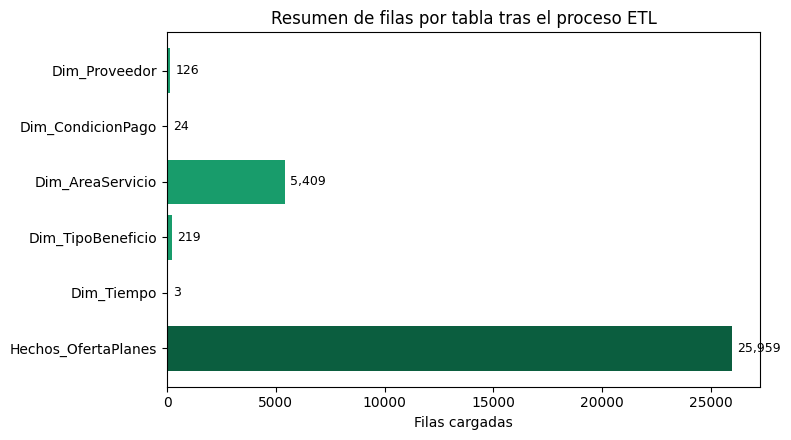

In [24]:
import matplotlib.pyplot as plt

tablas_nombres = ["Dim_Proveedor", "Dim_CondicionPago", "Dim_AreaServicio",
                   "Dim_TipoBeneficio", "Dim_Tiempo", "Hechos_OfertaPlanes"]
tablas_filas = [126, 24, 5409, 219, 3, 25959]

colores = ["#189c6b", "#189c6b", "#189c6b", "#189c6b", "#189c6b", "#0b5e3f"]

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(tablas_nombres, tablas_filas, color=colores)

ax.set_xlabel("Filas cargadas")
ax.set_title("Resumen de filas por tabla tras el proceso ETL")
ax.invert_yaxis()

for barra, valor in zip(barras, tablas_filas):
    ax.text(barra.get_width() + max(tablas_filas) * 0.01, barra.get_y() + barra.get_height()/2,
             f"{valor:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

_Nota: la tabla de hechos (en verde oscuro, para diferenciarla de las dimensiones) concentra la mayor cantidad de registros, como es esperado en un esquema estrella. Dim_AreaServicio es la dimensión con más filas debido a su granularidad geográfica, mientras que Dim_Tiempo, al ser generada de forma independiente y no desde una fuente transaccional, tiene solo 3 registros (2017, 2018, y el registro comodín)._

### 9.2 Cobertura de los análisis de negocio

| Análisis | Estado tras el ETL |
|---|---|
| 1. Comportamiento desleal de proveedores | Viable. Hechos_OfertaPlanes permite comparar valorCopago/valorCoseguro por Dim_TipoBeneficio y Dim_Proveedor. Los 7,987 registros con IdTipoBeneficio_DWH = 0 (huérfanos) deben excluirse o tratarse aparte en el análisis, dado que no tienen tipo de beneficio identificado. |
| 2. Cobertura de planes | Viable. Dim_AreaServicio quedó reducida a 5,409 áreas (coincide con el dato de negocio de RaSA), permitiendo contar cobertura por proveedor sin el ruido de duplicados detectado en la Entrega 1. |
| 3. Concentraciones de planes | Viable con limitación: al reducir el grano de Dim_AreaServicio a un registro por área (sin el detalle de Condado por fila), el análisis de concentración a nivel de condado requiere un tratamiento adicional o una fuente complementaria que confirme la relación área-condado completa, dado que Hechos_OfertaPlanes no permite recuperar ese detalle. |
| 4. Evolución de planes | Viable. Dim_TipoBeneficio (SCD Tipo 2) permite comparar configuraciones de beneficio entre 2017 y 2018. La resolución del grano ambiguo por primera ocurrencia (Bloque 4) implica que la evolución reportada corresponde a una configuración representativa, no a todas las variantes originales de la fuente. |

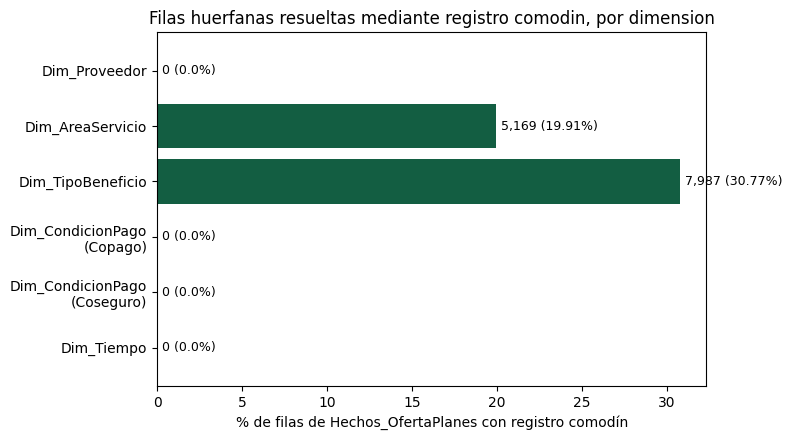

In [26]:
dimensiones_huerfanos = ["Dim_Proveedor", "Dim_AreaServicio", "Dim_TipoBeneficio",
                          "Dim_CondicionPago\n(Copago)", "Dim_CondicionPago\n(Coseguro)", "Dim_Tiempo"]
filas_huerfanas = [0, 5169, 7987, 0, 0, 0]
total_hechos = 25959
porcentajes = [round(f / total_hechos * 100, 2) for f in filas_huerfanas]

colores_huerfanos = ["#189c6b", "#135e42", "#135e42", "#189c6b", "#189c6b", "#189c6b"]

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(dimensiones_huerfanos, porcentajes, color=colores_huerfanos)

ax.set_xlabel("% de filas de Hechos_OfertaPlanes con registro comodín")
ax.set_title("Filas huerfanas resueltas mediante registro comodin, por dimension")
ax.invert_yaxis()

for barra, valor, pct in zip(barras, filas_huerfanas, porcentajes):
    ax.text(barra.get_width() + 0.3, barra.get_y() + barra.get_height()/2,
             f"{valor:,} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

_Nota: Dim_AreaServicio y Dim_TipoBeneficio (en rojo) son las únicas dimensiones con huérfanos, consistentes con los hallazgos de integridad referencial de la Entrega 1. El resto de dimensiones no presenta huérfanos. Estas dos limitaciones son las que se trasladan como prioritarias a RaSA en la sección 9.3._

### 9.3 Limitaciones y dudas trasladadas a RaSA

Este diseño resuelve los problemas de calidad e integración identificados en
la Entrega 1 mediante supuestos documentados explícitamente en cada bloque
(sección 7.2). Las decisiones con mayor impacto sobre los análisis de negocio,
y que ameritan confirmación prioritaria de RaSA antes de una carga definitiva,
son:

- La reducción de grano de Dim_AreaServicio (pérdida del detalle de Condado por fila), que condiciona el Análisis 3.
- La resolución del grano ambiguo de Dim_TipoBeneficio por primera ocurrencia, que condiciona la precisión del Análisis 1 y 4.
- La ausencia de una base de datos destino confirmada, que impide validar este diseño mediante una carga real.